# The Importance of Data Visualization in Data Science

**Objective:** This notebook demostrates why data visualization is essential in data science, using the famous **Anscombe's Quartet** dataset that shows how datasets with nearly identical statistical properties can have completely different distributions.

In [20]:
# Import Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("All libraries imported successfully!")


All libraries imported successfully!


## Introduction to Anscombe's Quartet

**Anscombe's Quartet** is a collection of four datasets that have nearly identical simple descriptive statistics (mean, variance, correlation, etc.), but appear very different when graphed.

This demonstrates why **data visualization** is essential - summary statistics alone can be misleading!

In [21]:
# Load Anscombe's Quartet dataset
anscombe = sns.load_dataset("anscombe")
print("======== Anscombe's Quartet Dataset ========")
print(anscombe.head(10))

======== Anscombe's Quartet Dataset ========
  dataset     x      y
0       I  10.0   8.04
1       I   8.0   6.95
2       I  13.0   7.58
3       I   9.0   8.81
4       I  11.0   8.33
5       I  14.0   9.96
6       I   6.0   7.24
7       I   4.0   4.26
8       I  12.0  10.84
9       I   7.0   4.82


In [22]:
# Let's examine the structure of the data set
print("======== Dataset structure ========")
print(f"Shape: {anscombe.shape}")
print(f"Dataset column names: {anscombe.columns.to_list()}")
print(f"Unique datasets: {anscombe['dataset'].unique()}")


======== Dataset structure ========
Shape: (44, 3)
Dataset column names: ['dataset', 'x', 'y']
Unique datasets: ['I' 'II' 'III' 'IV']


## Statistical Summary of All Four Datasets

Let's first calculate the key statistical properties for each dataset to see how similar they appear numerically.

In [ ]:
# Calculate summary statistics for each dataset
summary_stats = []
dataset_names = anscombe['dataset'].unique()

for dataset_name in dataset_names:

    subset = anscombe[anscombe['dataset'] == dataset_name]
    linreg_result = stats.linregress(subset['x'], subset['y'])
    stats_dict = {
        'Dataset': dataset_name,
        'Mean X': np.mean(subset['x']),
        'Mean Y': np.mean(subset['y']),
        'Variance X': np.var(subset['x'], ddof=1), # Sample variance
        'Variance Y': np.var(subset['y']),
        'Correlation': subset['x'].corr(subset['y']),
        'Linear Regression Slope': linreg_result.slope,
        'Linear Regression Intercept': linreg_result.intercept,
        'R-squared': linreg_result.rvalue**2
    }
    summary_stats.append(stats_dict)

# Create summary dataframe
summary_df = pd.DataFrame(summary_stats)
print("======== Statistical Summary of All Four Datasets ========")
print(summary_df.round(3))

======== Statistical Summary of All Four Datasets ========
  Dataset  Mean X  Mean Y  Variance X  Variance Y  Correlation  \
0       I     9.0   7.501        11.0       3.752        0.816   
1      II     9.0   7.501        11.0       3.752        0.816   
2     III     9.0   7.500        11.0       3.748        0.816   
3      IV     9.0   7.501        11.0       3.748        0.817   

   Linear Regression Slope  Linear Regression Intercept  R-squared  
0                      0.5                        3.000      0.667  
1                      0.5                        3.001      0.666  
2                      0.5                        3.002      0.666  
3                      0.5                        3.002      0.667  


## The Critical Insight: Visualizing the Dataset

Now let's plot all four datasets to reveal their true nature.

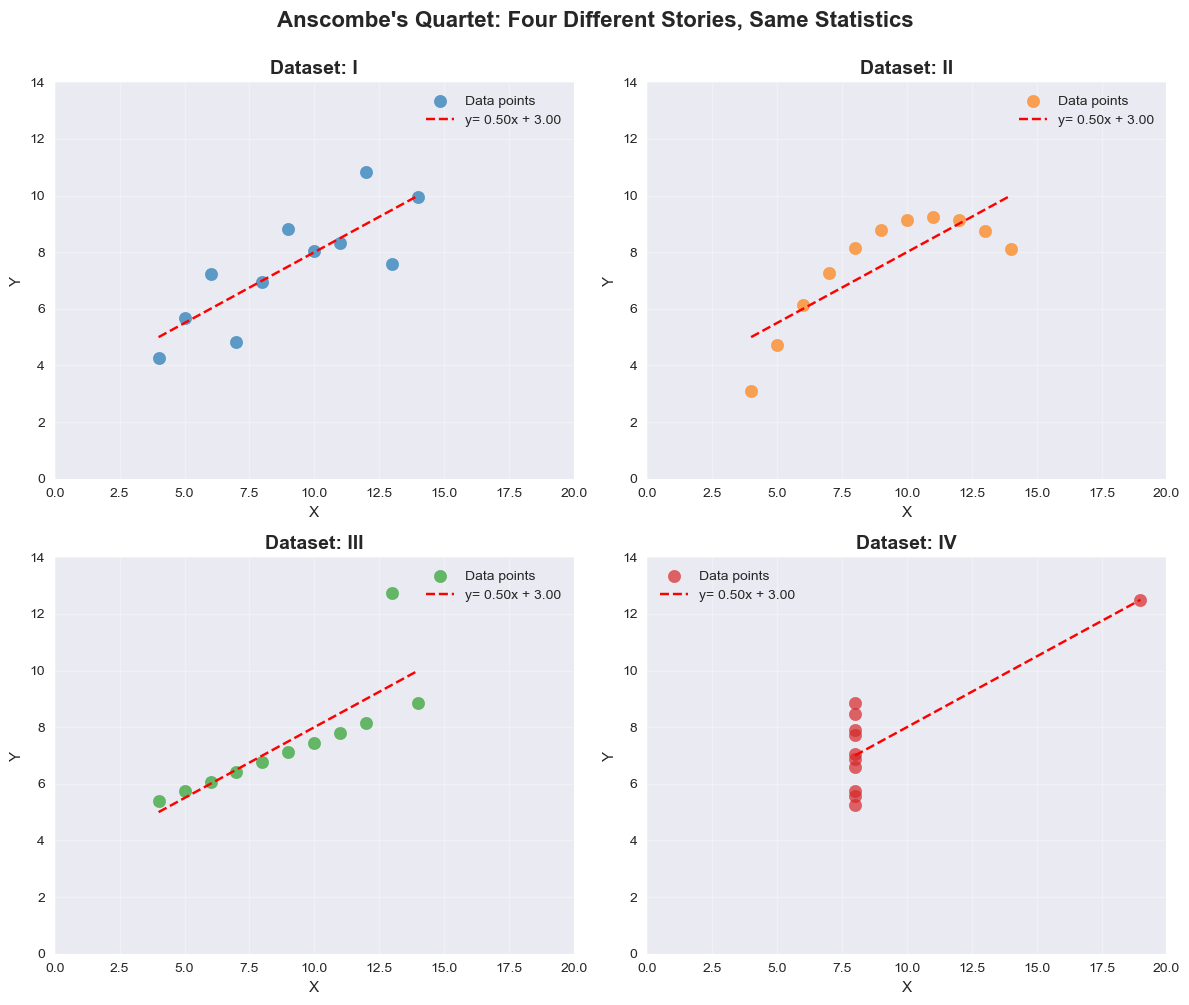

In [69]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Anscombe's Quartet: Four Different Stories, Same Statistics", fontsize=16, fontweight="bold", y=1)

# Colors for different datasets
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']


for i, dataset_name in enumerate(dataset_names):

    row = i // 2
    col = i % 2

    subset = anscombe[anscombe['dataset'] == dataset_name]

    # Plot the data points
    axes[row, col].scatter(subset['x'], subset['y'], color=colors[i], s=80, alpha=0.7, label='Data points')

    # Add regression line
    slope, intercept, r_value, p_value, std_err = linreg_result
    x_line = np.array([subset['x'].min(), subset['x'].max()])
    y_line = intercept + slope * x_line
    axes[row, col].plot(x_line, y_line, color='red', linestyle='--', label=f"y= {slope:.2f}x + {intercept:.2f}")

    # Customize each subplot
    axes[row, col].set_title(f"Dataset: {dataset_name}", fontsize=14, fontweight="bold")
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

    # Set consistent axis limits for better comparison
    axes[row, col].set_xlim(0, 20)
    axes[row, col].set_ylim(0, 14)

plt.tight_layout()
plt.show()

## Detailed Analysis of Each Dataset

Let's analyze each dataset individually for more detail

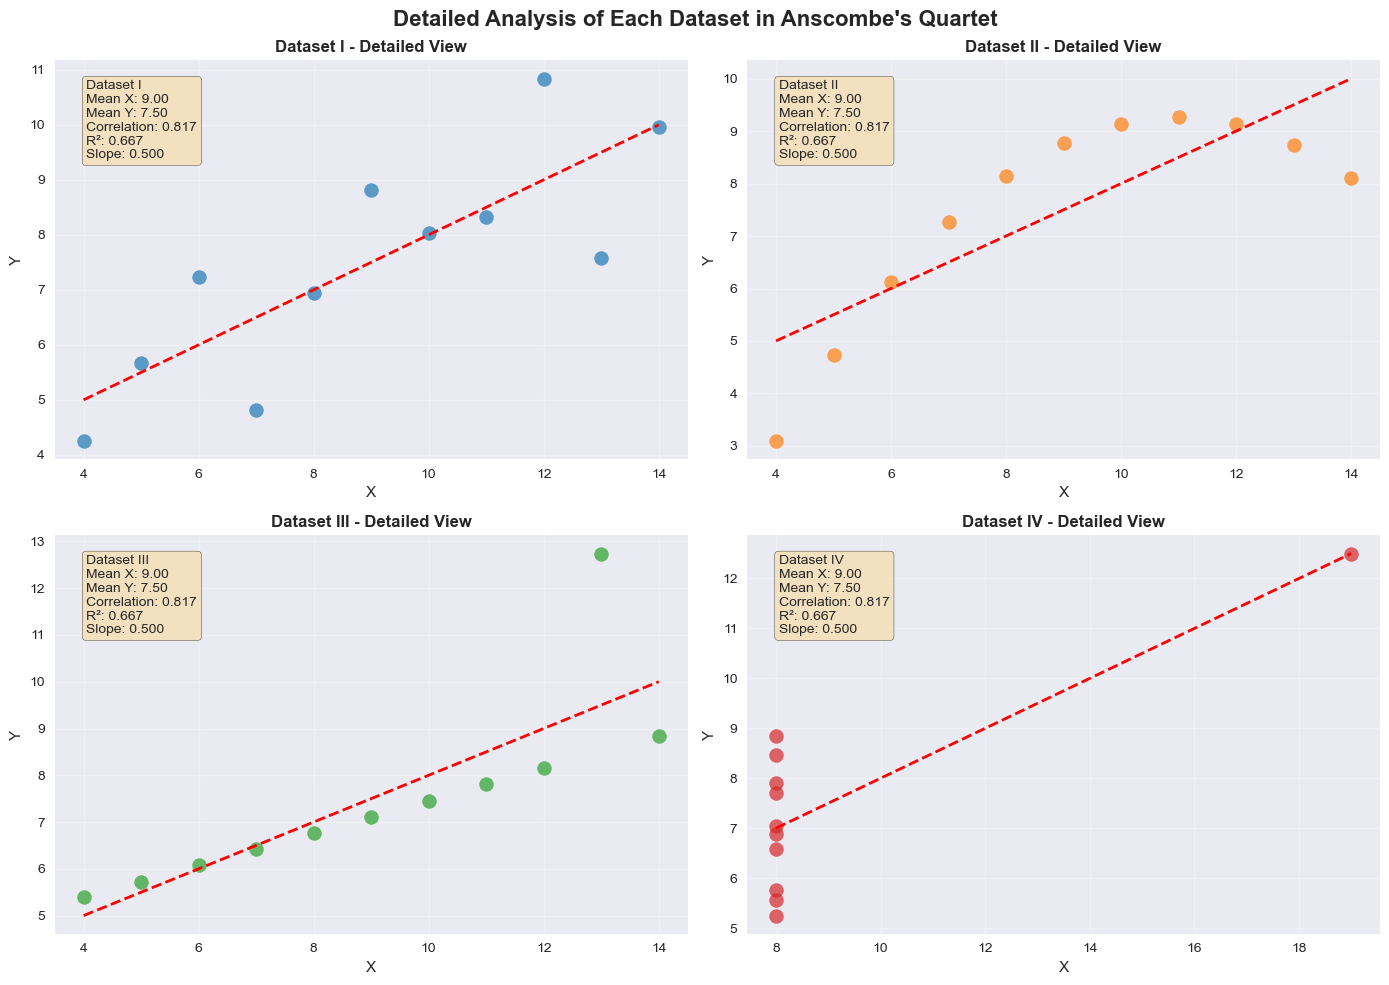

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, dataset_name in enumerate(dataset_names):
    row = i // 2
    col = i % 2
    
    subset = anscombe[anscombe['dataset'] == dataset_name]
    
    # Main scatter plot
    scatter = axes[row, col].scatter(subset['x'], subset['y'], color=colors[i], s=100, alpha=0.7)
    
    # Regression line
    slope, intercept, r_value, p_value, std_err = linreg_result
    x_line = np.linspace(subset['x'].min(), subset['x'].max(), 100)
    y_line = intercept + slope * x_line
    axes[row, col].plot(x_line, y_line, color='red', linewidth=2, linestyle='--')
    
    # Add statistical annotations
    stats_text = f'''Dataset {dataset_name}
Mean X: {np.mean(subset['x']):.2f}
Mean Y: {np.mean(subset['y']):.2f}
Correlation: {r_value:.3f}
R²: {r_value**2:.3f}
Slope: {slope:.3f}'''
    
    axes[row, col].text(0.05, 0.95, stats_text, transform=axes[row, col].transAxes, 
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[row, col].set_title(f'Dataset {dataset_name} - Detailed View', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Detailed Analysis of Each Dataset in Anscombe\'s Quartet', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()